# ERA5 vs Station Observations — Baseline Error (2016–2022)

## 1. Aim

How much error already exists between gridded **ERA5** reanalysis and local **station
observations**, independent of any forecast model? This notebook answers that on its own.

It is extracted from Section 9 of `model_comparison_analysis_72h_interpolate.ipynb`, where it
served as context for the FCN3/GraphCast/HRES-vs-Obs numbers ("if ERA5 itself has large local
errors, models that lean on ERA5-like input may inherit some of that error"). Here it stands on
its own as the ERA5-vs-Obs baseline, at the same 12 stations across Troms, Nordland and
Finnmark, 2016–2022.

**Spatial matching**: ERA5 is bilinear-interpolated (`xarray.interp(..., method="linear")`) to
each station's exact coordinates, matching the approach used by
[stationbench](https://github.com/juaAI/stationbench), instead of snapping to the nearest 0.25°
grid cell.


## 2. Data

- **ERA5** — 0.25°, 6-hourly reanalysis 10 m wind speed (`sqrt(u10^2 + v10^2)`), bilinear-
  interpolated to each station's exact coordinates.
- **Station observations** — hourly wind speed from the Frost API, matched to ERA5 valid times
  (00:00, 06:00, 12:00, 18:00 UTC).

Same 12 stations used throughout this project (Troms, Nordland, Finnmark).


In [1]:
import sys
# scipy (required for .interp(method='linear')) lives here instead of the env's own
# site-packages, because /cluster/projects/nn8106k has run out of inodes — see project notes.
sys.path.insert(0, '/cluster/work/projects/nn8106k/siyan/pip_cache')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
ERA5_DIR = Path('/cluster/work/projects/nn8106k/siyan/era5_6h')
OBS_DIR  = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')
OUT_ROOT = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study')
FIG_DIR  = OUT_ROOT / 'figures_era5_vs_obs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reuses the same cache the interpolation notebook (Section 9) already wrote, so this
# notebook loads instantly if that one has been run at least once.
CSV_ERA5_OBS = OUT_ROOT / 'era5_vs_obs_dataset_interp.csv'

YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022]

STATIONS = [
    {'id': 'SN88690', 'name': 'Hekkingen Fyr',     'lat': 69.6005, 'lon': 17.8317, 'county': 'Troms',    'obs_base': 'SN88690_Hekkingen_Fyr'},
    {'id': 'SN90490', 'name': 'Tromsø-Langnes',     'lat': 69.6767, 'lon': 18.9133, 'county': 'Troms',    'obs_base': 'SN90490_Tromsoe_Langnes'},
    {'id': 'SN90760', 'name': 'Fakken',             'lat': 70.1043, 'lon': 20.1145, 'county': 'Troms',    'obs_base': 'SN90760_Fakken'},
    {'id': 'SN90800', 'name': 'Torsvåg Fyr',        'lat': 70.2450, 'lon': 19.5000, 'county': 'Troms',    'obs_base': 'SN90800_Torsvag_Fyr'},
    {'id': 'SN90720', 'name': 'Måsvik',             'lat': 69.9900, 'lon': 18.6940, 'county': 'Troms',    'obs_base': 'SN90720_Masvik'},
    {'id': 'SN91740', 'name': 'Sørkjosen Lufthavn', 'lat': 69.7900, 'lon': 20.9520, 'county': 'Troms',    'obs_base': 'SN91740_Sorkjosen_Lufthavn'},
    {'id': 'SN89350', 'name': 'Bardufoss',          'lat': 69.0580, 'lon': 18.5440, 'county': 'Troms',    'obs_base': 'SN89350_Bardufoss'},
    {'id': 'SN87110', 'name': 'Andøya',             'lat': 69.3070, 'lon': 16.1310, 'county': 'Nordland', 'obs_base': 'SN87110_Andoya'},
    {'id': 'SN85380', 'name': 'Skrova Fyr',         'lat': 68.1530, 'lon': 14.6490, 'county': 'Nordland', 'obs_base': 'SN85380_Skrova_Fyr'},
    {'id': 'SN94500', 'name': 'Fruholmen Fyr',      'lat': 71.0940, 'lon': 23.9840, 'county': 'Finnmark', 'obs_base': 'SN94500_Fruholmen_Fyr'},
    {'id': 'SN96400', 'name': 'Slettnes Fyr',       'lat': 71.0890, 'lon': 28.2170, 'county': 'Finnmark', 'obs_base': 'SN96400_Slettnes_Fyr'},
    {'id': 'SN95350', 'name': 'Banak',              'lat': 70.0600, 'lon': 24.9790, 'county': 'Finnmark', 'obs_base': 'SN95350_Banak'},
]
STATIONS_BY_ID = {s['id']: s for s in STATIONS}
STATION_ORDER  = [s['id'] for s in STATIONS]
STATION_LABELS = [s['name'] for s in STATIONS]

CLR = {'ERA5': '#8E44AD'}

print(f'Config loaded. YEARS={YEARS}')


Config loaded. YEARS=[2016, 2017, 2018, 2019, 2020, 2021, 2022]


## 3. Data Loading

Standardized loaders, each returning `(station, valid_time, ...)`:

- ERA5: `(station, valid_time, era5_wind)`
- Station obs: `(station, valid_time, obs_wind)`

ERA5 is cropped to a small box around the 12 stations *before* interpolating — `.interp
(method="linear")` needs scipy and, unlike nearest-neighbor `.sel()`, materializes the selected
lat/lon slice into memory for every timestep. Without cropping first, each call would
materialize the entire global 0.25° grid (721x1440) per timestep.


In [2]:
# Crop to a small bounding box around the 12 stations *before* interpolating.
_STATION_LAT_MARGIN = 2.0  # degrees, wide enough for linear interp's 2 nearest gridpoints
_STATION_LON_MARGIN = 2.0

_lat_min = min(s['lat'] for s in STATIONS) - _STATION_LAT_MARGIN
_lat_max = max(s['lat'] for s in STATIONS) + _STATION_LAT_MARGIN
_lon_min = (min(s['lon'] for s in STATIONS) % 360) - _STATION_LON_MARGIN
_lon_max = (max(s['lon'] for s in STATIONS) % 360) + _STATION_LON_MARGIN


def _crop_to_stations(da: xr.DataArray) -> xr.DataArray:
    """Subset a global lat/lon DataArray to a small box around the 12 stations.

    Handles both ascending and descending latitude/longitude coordinate order (ERA5
    here is lat-descending), since `.sel(slice(...))` silently returns an empty
    selection if the slice direction doesn't match the coordinate's own order.
    """
    lat_asc = bool(da.latitude.values[0] < da.latitude.values[-1])
    lon_asc = bool(da.longitude.values[0] < da.longitude.values[-1])
    lat_slice = slice(_lat_min, _lat_max) if lat_asc else slice(_lat_max, _lat_min)
    lon_slice = slice(_lon_min, _lon_max) if lon_asc else slice(_lon_max, _lon_min)
    return da.sel(latitude=lat_slice, longitude=lon_slice)


print(f'Station bounding box for interpolation: lat [{_lat_min:.2f}, {_lat_max:.2f}], '
      f'lon [{_lon_min:.2f}, {_lon_max:.2f}]')


Station bounding box for interpolation: lat [66.15, 73.09], lon [12.65, 30.22]


In [3]:
def load_obs(year: int) -> pd.DataFrame:
    """Load hourly station wind speed from Frost API CSVs.
    Returns (station, valid_time, obs_wind) — one row per station-hour.
    """
    parts = []
    for st in STATIONS:
        f = OBS_DIR / f"{st['obs_base']}_{year}.csv"
        if not f.exists():
            print(f'  [obs] Missing: {f.name}')
            continue
        df = pd.read_csv(f)
        df['valid_time'] = (pd.to_datetime(df['time'], utc=True)
                              .dt.tz_convert(None))
        df['station']   = st['id']
        df['obs_wind']  = pd.to_numeric(df['wind_speed'], errors='coerce')
        parts.append(
            df[['station', 'valid_time', 'obs_wind']].dropna()
        )
    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'obs_wind'])
    return (pd.concat(parts, ignore_index=True)
              .sort_values('valid_time')
              .reset_index(drop=True))


In [4]:
def load_era5(year: int) -> pd.DataFrame:
    """Extract ERA5 10m wind speed at station locations via bilinear interpolation
    (method='linear'), matching stationbench's spatial-matching approach
    (https://github.com/juaAI/stationbench) instead of nearest-neighbor.
    ERA5 is 6-hourly → valid times at 00:00, 06:00, 12:00, 18:00 UTC.
    Returns (station, valid_time, era5_wind).
    """
    f = ERA5_DIR / f'era5_single_{year}.nc'
    if not f.exists():
        print(f'  [ERA5] Missing: {f.name}')
        return pd.DataFrame(columns=['station', 'valid_time', 'era5_wind'])

    ds  = xr.open_dataset(str(f))
    # Crop BEFORE computing wind speed, not after: without dask in this env,
    # u10**2 + v10**2 forces immediate computation over the FULL global grid
    # (~70s/year measured), vs ~1.6s/year once cropped first.
    u10 = _crop_to_stations(ds['u10'])
    v10 = _crop_to_stations(ds['v10'])
    ws  = np.sqrt(u10 ** 2 + v10 ** 2)   # 10m wind speed

    station_lat = xr.DataArray([st['lat'] for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    station_lon = xr.DataArray([st['lon'] % 360 for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    ws_interp = ws.interp(latitude=station_lat, longitude=station_lon, method='linear')

    df = (ws_interp.to_dataframe(name='era5_wind')
          .reset_index()[['station', 'valid_time', 'era5_wind']]
          .dropna(subset=['era5_wind']))
    ds.close()
    return df.sort_values(['station', 'valid_time']).reset_index(drop=True)


## 4. Metric Definitions

$$\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)^2} \qquad
\mathrm{MAE} = \frac{1}{N}\sum_{i=1}^{N}|\hat y_i - y_i| \qquad
\mathrm{Bias} = \frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)$$

$$\mathrm{nRMSE} = \frac{\mathrm{RMSE}}{\bar y}\times 100\% \qquad
\mathrm{nBias} = \frac{\mathrm{Bias}}{\bar y}\times 100\% \qquad
r = \mathrm{corr}(\hat y, y)$$

Here $\hat y$ = ERA5 wind speed, $y$ = station Obs wind speed:

- **RMSE** — average magnitude of ERA5's error vs Obs.
- **MAE** — average absolute error, less sensitive to extreme errors than RMSE.
- **Bias** — systematic over- (positive) or under- (negative) estimation by ERA5.
- **nRMSE / nBias** — RMSE/Bias normalized by mean Obs wind speed ($\bar y$), useful when
  stations have different average wind speeds.
- **Corr** — Pearson correlation between ERA5 and Obs; checks whether ERA5 captures temporal
  variability, not just the right average magnitude.

```python
METRICS = ["RMSE", "MAE", "Bias", "nRMSE", "nBias", "Corr"]
```


In [5]:
def compute_group_metrics(df, pred_col, ref_col, group_cols):
    """Grouped RMSE/MAE/Bias/nRMSE/nBias/Corr between pred_col and ref_col."""
    def _agg(g):
        s = g.dropna(subset=[pred_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan,
                               'nRMSE': np.nan, 'nBias': np.nan, 'Corr': np.nan})
        err  = s[pred_col] - s[ref_col]
        rmse = float(np.sqrt((err ** 2).mean()))
        mae  = float(err.abs().mean())
        bias = float(err.mean())
        mean_ref = float(s[ref_col].mean())
        nrmse = rmse / mean_ref * 100 if mean_ref else np.nan
        nbias = bias / mean_ref * 100 if mean_ref else np.nan
        corr  = float(s[pred_col].corr(s[ref_col])) if n > 1 else np.nan
        return pd.Series({'N': n, 'RMSE': rmse, 'MAE': mae, 'Bias': bias,
                           'nRMSE': nrmse, 'nBias': nbias, 'Corr': corr})
    return df.groupby(group_cols).apply(_agg).reset_index()


## 5. ERA5 vs Station Obs — Overall and by Station

The ERA5-vs-Obs baseline itself: how much error already exists between gridded ERA5 and local
station observations, before any forecast model is involved.


In [6]:
if CSV_ERA5_OBS.exists():
    era5_obs_df = pd.read_csv(CSV_ERA5_OBS, parse_dates=['valid_time'])
    print(f'Loaded from cache: {CSV_ERA5_OBS.name}  ({len(era5_obs_df):,} rows)')
else:
    parts = []
    for year in YEARS:
        e = load_era5(year)
        o = load_obs(year)
        for df in [e, o]:
            if not df.empty:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')
        m = e.merge(o, on=['station', 'valid_time'], how='inner')
        if m.empty:
            continue
        m['year'] = year
        parts.append(m)
    era5_obs_df = pd.concat(parts, ignore_index=True).rename(
        columns={'era5_wind': 'era5', 'obs_wind': 'obs'})
    era5_obs_df.to_csv(CSV_ERA5_OBS, index=False)
    print(f'Saved: {CSV_ERA5_OBS}  ({len(era5_obs_df):,} rows)')

# Station-level evaluation: average across the 12 stations, each weighted equally,
# rather than pooling all stations' samples into one RMSE/Bias/etc.
era5_obs_by_station = compute_group_metrics(era5_obs_df, 'era5', 'obs', ['station'])
era5_vs_obs_overall = (era5_obs_by_station[['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']].mean()
                       .to_frame().T)
era5_vs_obs_overall.insert(0, 'Dataset', 'ERA5')
era5_vs_obs_overall.insert(1, 'N', era5_obs_by_station['N'].sum())

# Station-to-station std (12 stations), not a sampling CI
for _m in ['RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr']:
    era5_vs_obs_overall[f'{_m}_std_across_stations'] = era5_obs_by_station[_m].std()

print('=== ERA5 vs Station Obs — overall (12-station average, each station weighted equally) ===')
display(era5_vs_obs_overall.round(3))
print()
print('=== ERA5 vs Station Obs, by station ===')
display(era5_obs_by_station.assign(station=lambda d: d['station'].map(lambda s: STATIONS_BY_ID[s]['name']))
        .sort_values('RMSE', ascending=False).round(3))


Loaded from cache: era5_vs_obs_dataset_interp.csv  (122,615 rows)
=== ERA5 vs Station Obs — overall (12-station average, each station weighted equally) ===


,Dataset,N,RMSE,MAE,Bias,nRMSE,nBias,Corr,RMSE_std_across_stations,nRMSE_std_across_stations,Bias_std_across_stations,nBias_std_across_stations,Corr_std_across_stations
0,ERA5,122615.0,2.713,2.089,-0.893,50.191,-16.467,0.725,0.735,16.538,1.018,18.967,0.103



=== ERA5 vs Station Obs, by station ===


,station,N,RMSE,MAE,Bias,nRMSE,nBias,Corr
6,Fakken,10204.0,4.366,3.277,-2.474,55.317,-31.340,0.611
2,Hekkingen Fyr,10226.0,3.312,2.655,-0.790,52.783,-12.585,0.601
10,Banak,10227.0,3.293,2.554,-2.247,60.639,-41.380,0.759
4,Tromsø-Langnes,10228.0,3.049,2.333,-1.921,68.876,-43.388,0.668
8,Sørkjosen Lufthavn,10184.0,2.965,2.158,-1.724,72.535,-42.175,0.651
7,Torsvåg Fyr,10228.0,2.595,2.006,0.917,44.720,15.811,0.773
5,Måsvik,10214.0,2.508,1.941,-0.558,43.370,-9.643,0.763
0,Skrova Fyr,10226.0,2.456,1.905,-0.679,38.362,-10.601,0.748
11,Slettnes Fyr,10228.0,2.250,1.745,-0.769,32.291,-11.038,0.843
9,Fruholmen Fyr,10220.0,2.202,1.707,-0.476,28.141,-6.079,0.878


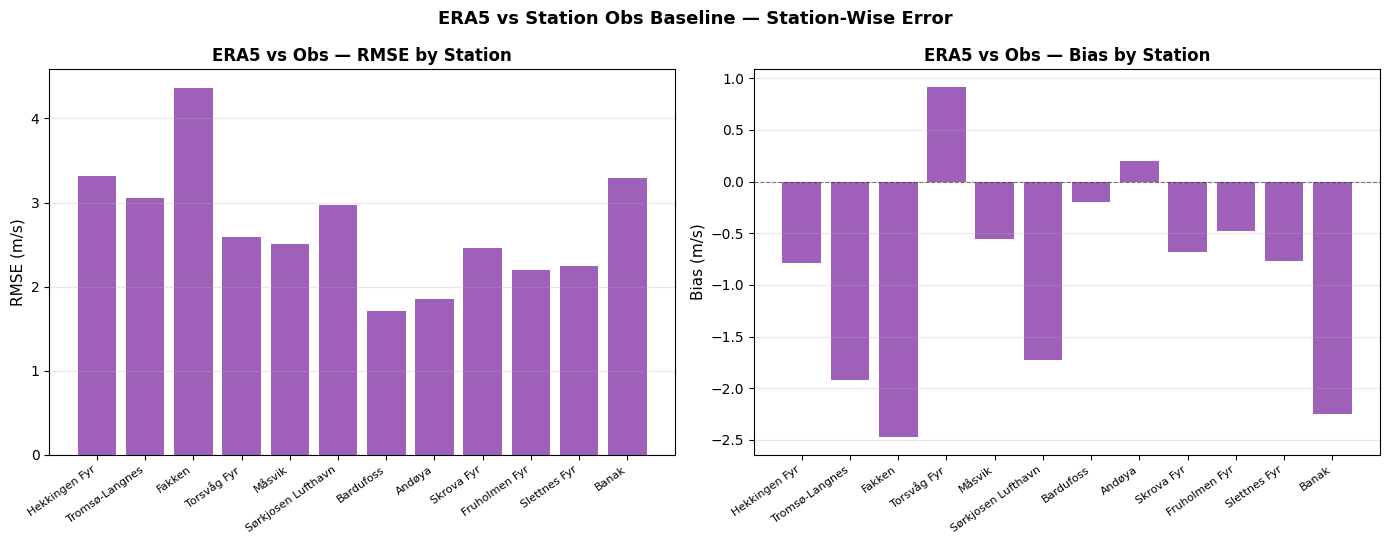

In [7]:
# Bar chart: ERA5-vs-Obs baseline error, broken down by station
era5_vs_obs_station = compute_group_metrics(era5_obs_df, 'era5', 'obs', ['station'])
era5_vs_obs_station = era5_vs_obs_station.set_index('station').reindex(STATION_ORDER)

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(STATION_ORDER))

ax_rmse.bar(x, era5_vs_obs_station['RMSE'], color=CLR['ERA5'], alpha=0.85)
ax_rmse.set_xticks(x); ax_rmse.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_rmse.set_ylabel('RMSE (m/s)', fontsize=11)
ax_rmse.set_title('ERA5 vs Obs — RMSE by Station', fontsize=12, fontweight='bold')
ax_rmse.grid(axis='y', alpha=0.3)

ax_bias.bar(x, era5_vs_obs_station['Bias'], color=CLR['ERA5'], alpha=0.85)
ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax_bias.set_xticks(x); ax_bias.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_bias.set_ylabel('Bias (m/s)', fontsize=11)
ax_bias.set_title('ERA5 vs Obs — Bias by Station', fontsize=12, fontweight='bold')
ax_bias.grid(axis='y', alpha=0.3)

fig.suptitle('ERA5 vs Station Obs Baseline — Station-Wise Error', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'era5_vs_obs_station_bar.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'era5_vs_obs_station_bar.pdf', bbox_inches='tight')
plt.show()
